# nr of clusters vs eps

## define visualisation functions

In [1]:
import json
import matplotlib.pyplot as plt


def plot_clustering_results(filename, title):
    with open(filename, "r") as f:
        clustering_results = json.load(f)

    plt.figure(figsize=(9, 6))

    for minPts in sorted({
        result["min_samples"]
        for result in clustering_results.values()
    }):
        results = [
            result
            for result in clustering_results.values()
            if result["min_samples"] == minPts
        ]

        # Sort by eps so the line is ordered correctly
        results = sorted(results, key=lambda x: x["eps"])

        eps = [result["eps"] for result in results]
        n_clusters = [result["n_clusters"] for result in results]

        plt.plot(
            eps,
            n_clusters,
            marker="o",
            label=f"minPts={minPts}"
        )

    plt.xlabel("eps")
    plt.ylabel("Number of clusters")
    plt.title(f"Number of clusters with varying epsilon and minPts ({title})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## bert-base

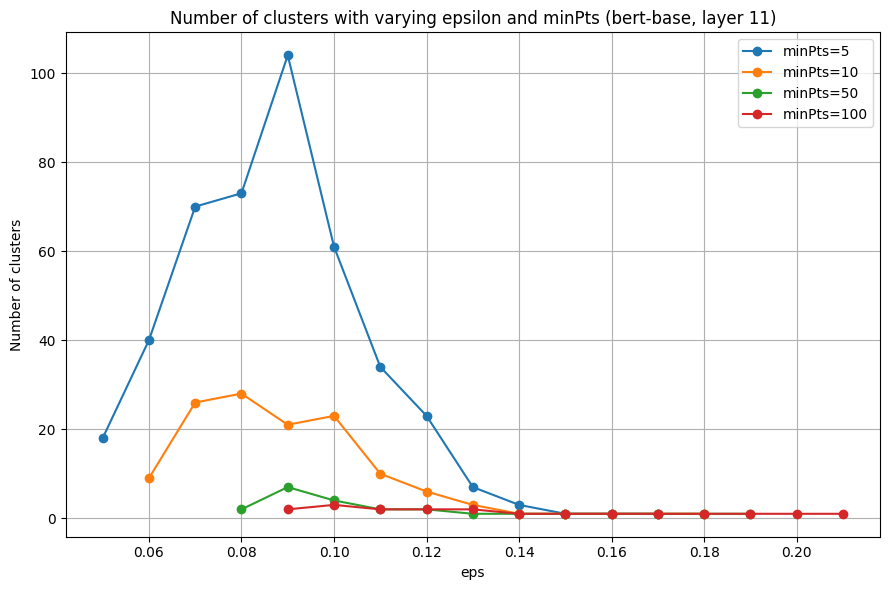

In [7]:
plot_clustering_results(
    "../results/dbscan_sample/clustering_results_bert-base_layer_11.json",
    "bert-base, layer 11"
)

nothing interesting more for eps > 0.16

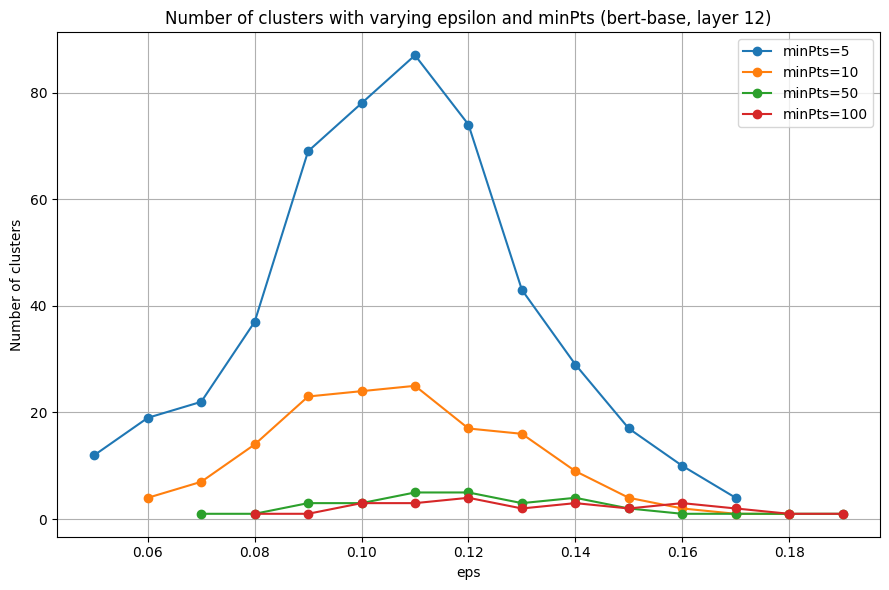

In [8]:
plot_clustering_results(
    "../results/dbscan_sample/clustering_results_bert-base_layer_12.json",
    "bert-base, layer 12"
)

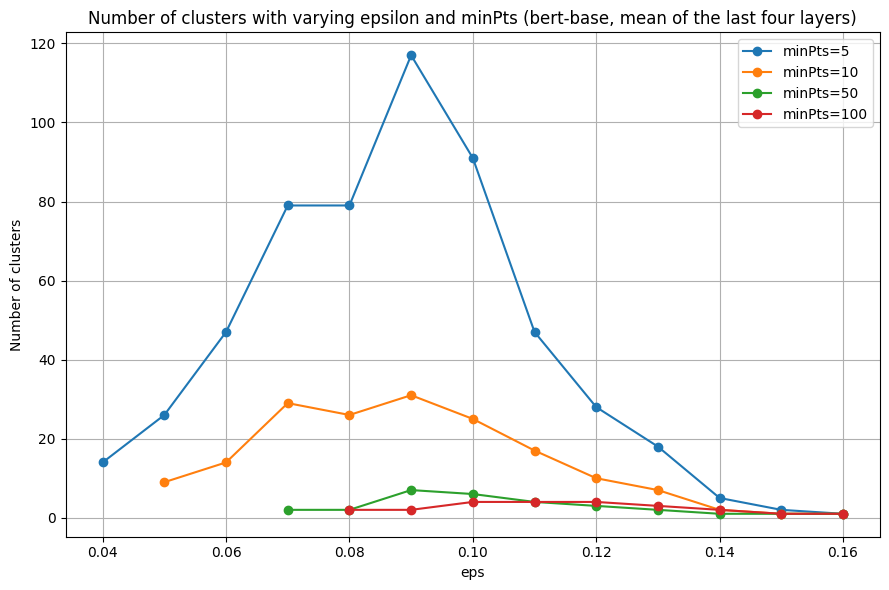

In [10]:
plot_clustering_results(
    "../results/dbscan_sample/clustering_results_bert-base_mean.json",
    "bert-base, mean of the last four layers"
)

## SciBERT

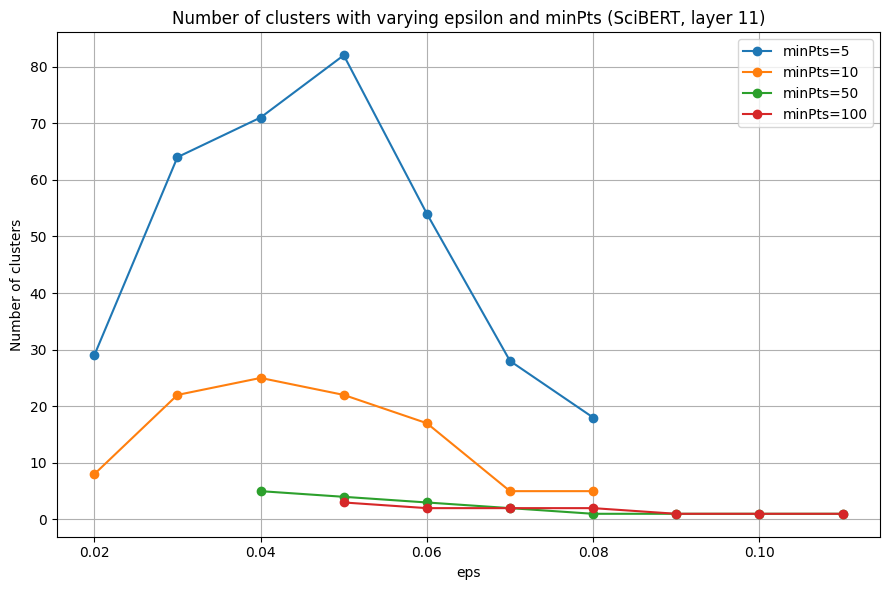

In [11]:
plot_clustering_results(
    "../results/dbscan_sample/clustering_results_scibert_layer_11.json",
    "SciBERT, layer 11"
)

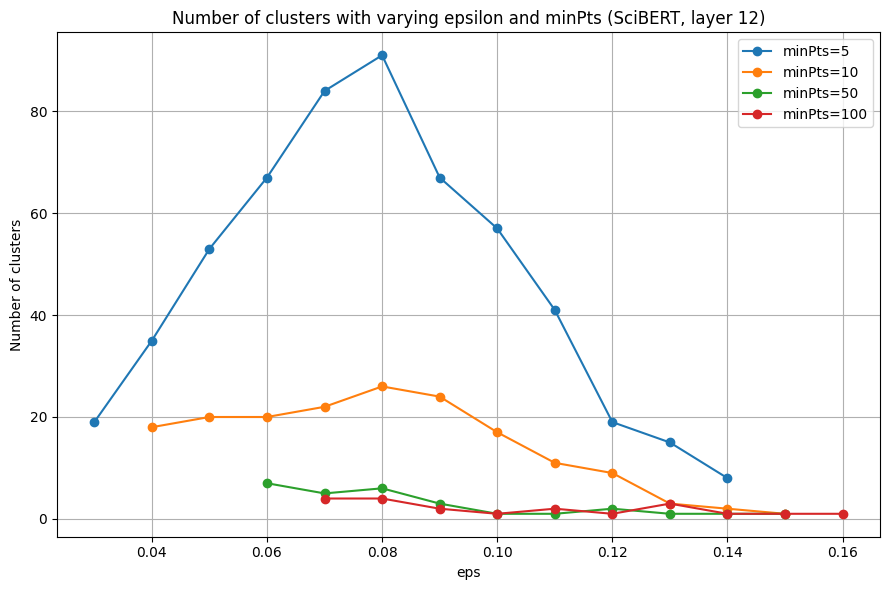

In [12]:
plot_clustering_results(
    "../results/dbscan_sample/clustering_results_scibert_layer_12.json",
    "SciBERT, layer 12"
)

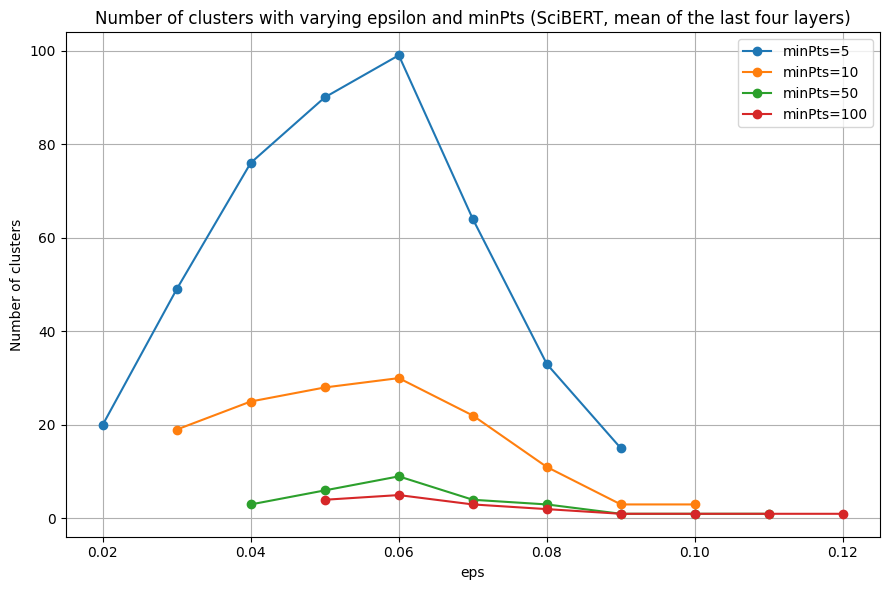

In [14]:
plot_clustering_results(
    "../results/dbscan_sample/clustering_results_scibert_layer_mean.json",
    "SciBERT, mean of the last four layers"
)

# noise vs largest component

## define the vis-function

In [51]:
import json
import matplotlib.pyplot as plt
import math


def plot_noise_largest_component(filename, title):
    with open(filename, "r") as f:
        clustering_results = json.load(f)

    minPts_values = sorted({
        result["min_samples"]
        for result in clustering_results.values()
    })

    # Two plots per row
    n_cols = 2
    n_rows = math.ceil(len(minPts_values) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 5 * n_rows),
        sharey=True,
        #sharex=True,
    )

    # Make axes iterable
    axes = axes.flatten()

    for ax, minPts in zip(axes, minPts_values):

        results = [
            result
            for result in clustering_results.values()
            if result["min_samples"] == minPts
        ]

        results = sorted(results, key=lambda x: x["eps"])

        eps = [
            result["eps"]
            for result in results
        ]

        # Noise as % of full dataset
        noise_pct = [
            100 * result["n_noise"] /
            result.get("n_samples", len(result["labels"]))
            for result in results
        ]

        # Largest component as % of full dataset
        largest_component_pct = [
            result["largest_cluster_pct"]
            for result in results
        ]

        # --------------------------------------------------------
        # Main lines
        # --------------------------------------------------------

        ax.plot(
            eps,
            noise_pct,
            marker="o",
            label="Noise"
        )

        ax.plot(
            eps,
            largest_component_pct,
            marker="o",
            label="Largest component"
        )

        # --------------------------------------------------------
        # Reference areas
        # --------------------------------------------------------

        # Blue area below 30%
        ax.fill_between(
            eps,
            0,
            30,
            color="blue",
            alpha=0.15,
            label="< 30%"
        )

        # Orange area above 50%
        #ax.fill_between(
        #    eps,
        #    50,
        #    100,
        #    color="orange",
        #    alpha=0.15,
        #    label="> 50%"
        #)

        # Threshold lines
        #ax.axhline(30, color="blue", linewidth=1)
        ax.axhline(50, color="orange", linewidth=1)

        ax.text(
            eps[-1],
            50 + 1,
            "max % largest cluster",
            color="orange",
            va="bottom",
            ha="right"
        )

        # --------------------------------------------------------
        # Formatting
        # --------------------------------------------------------

        ax.set_xlabel("eps")
        ax.set_title(f"minPts={minPts}")
        ax.set_ylim(0, 100)
        ax.grid(True)

    # Hide unused subplot if there is an odd number of minPts values
    for ax in axes[len(minPts_values):]:
        ax.set_visible(False)

    # Shared y-axis label
    axes[0].set_ylabel("% of full dataset")

    # One shared legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 1.02)
    )

    fig.suptitle(
        f"Noise vs largest component per epsilon and minPts({title})",
        y=1.08
    )

    plt.tight_layout()
    plt.show()


## bert-base

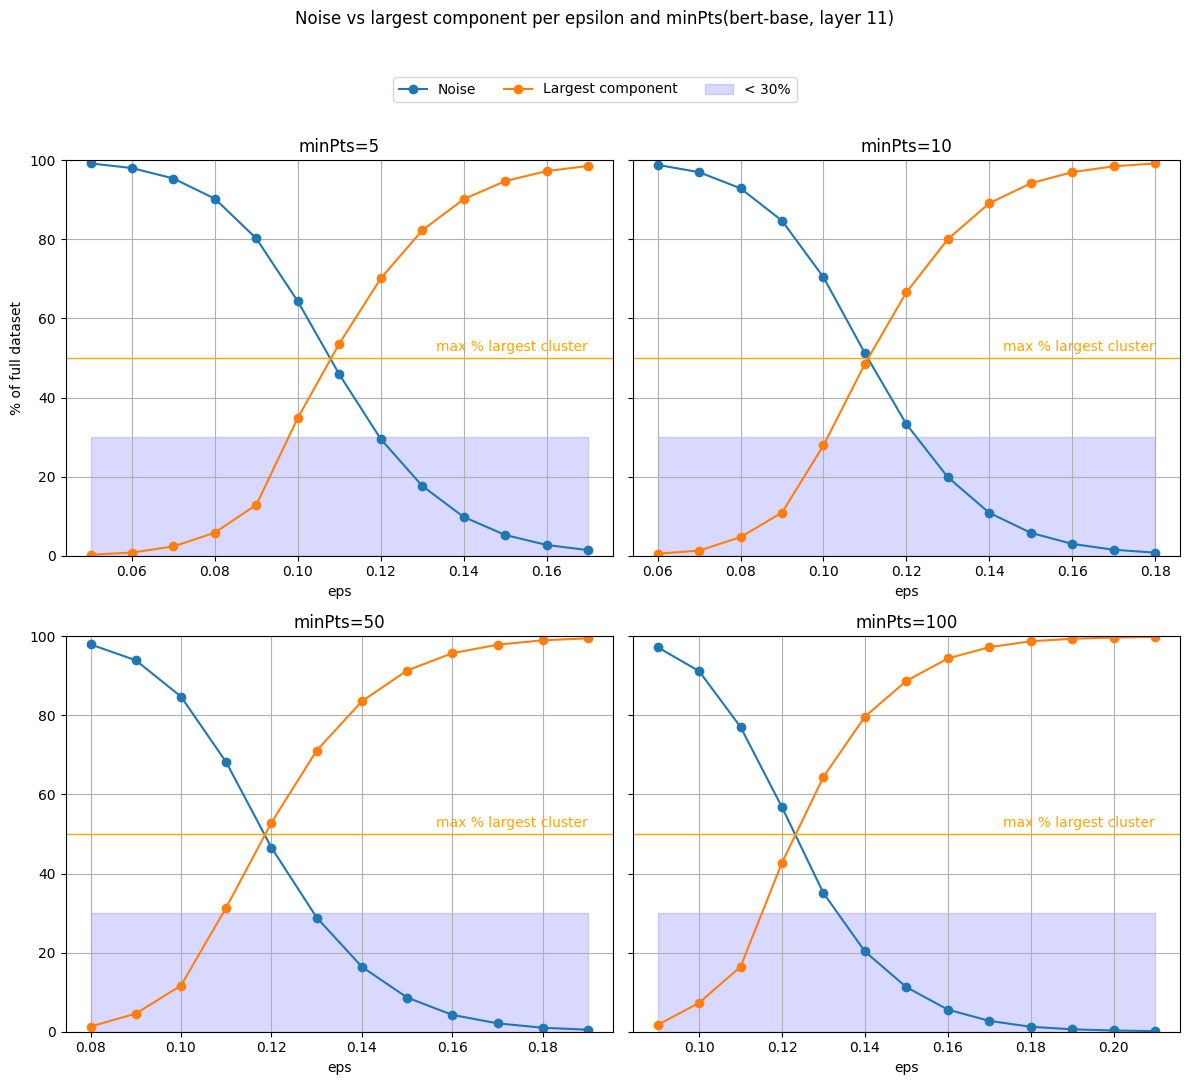

In [52]:
plot_noise_largest_component(
    "../results/dbscan_sample/clustering_results_bert-base_layer_11.json",
    "bert-base, layer 11"
)


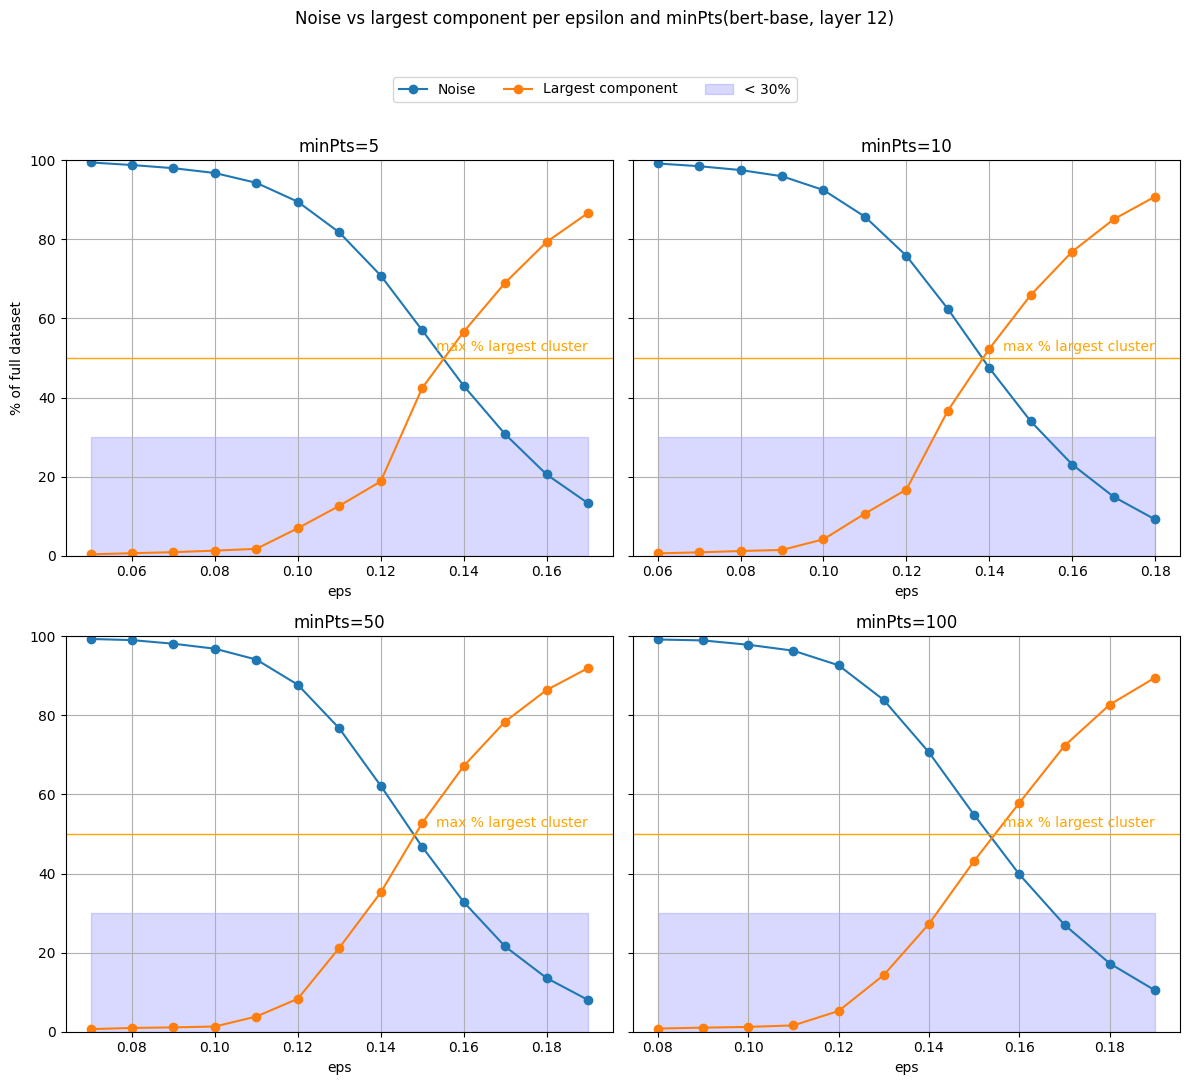

In [53]:
plot_noise_largest_component(
    "../results/dbscan_sample/clustering_results_bert-base_layer_12.json",
    "bert-base, layer 12"
)

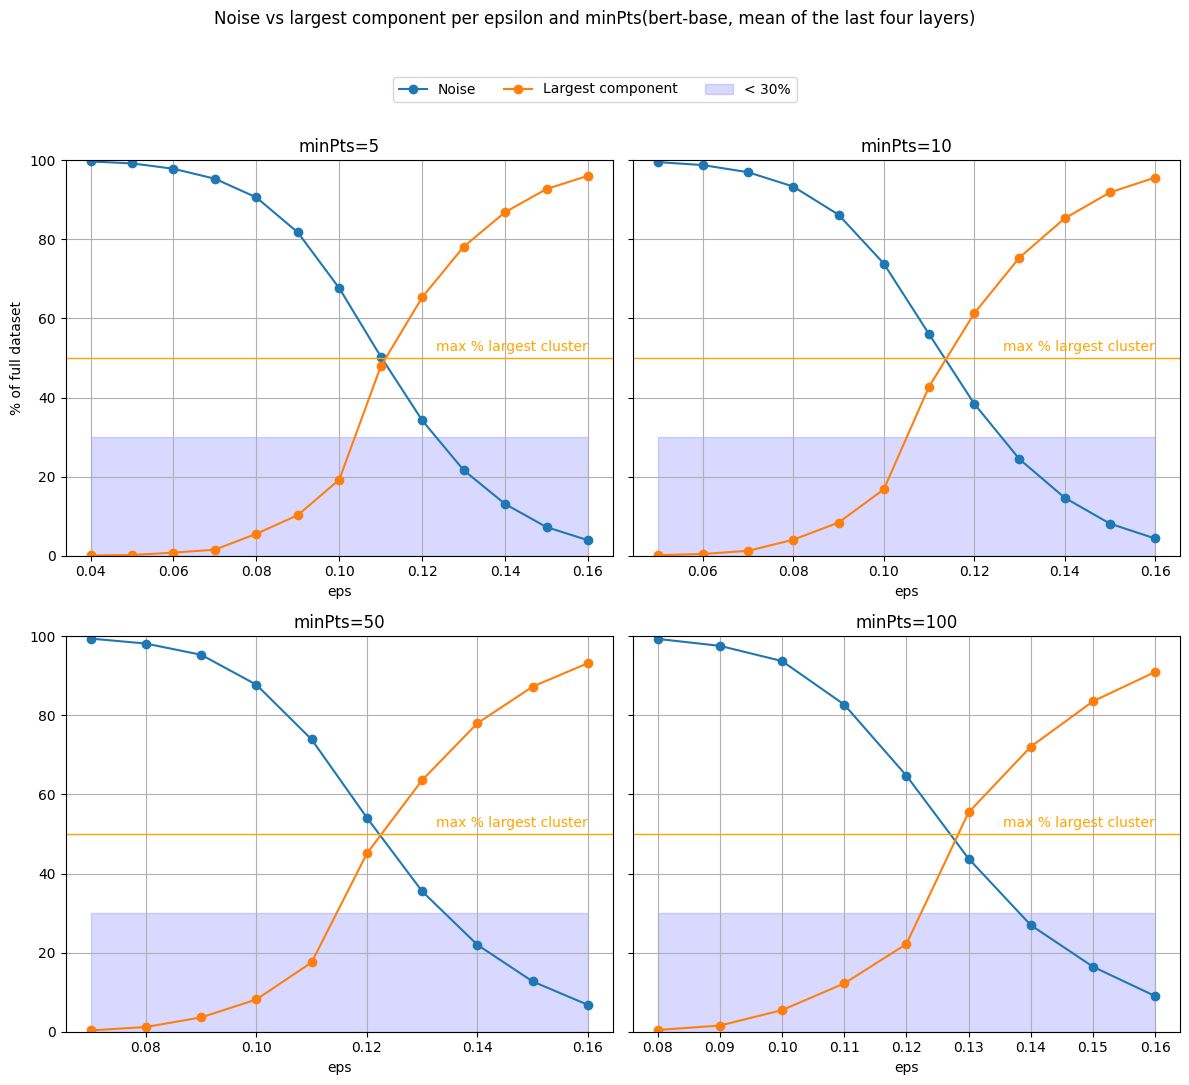

In [54]:
plot_noise_largest_component(
    "../results/dbscan_sample/clustering_results_bert-base_mean.json",
    "bert-base, mean of the last four layers"
)

## SciBERT

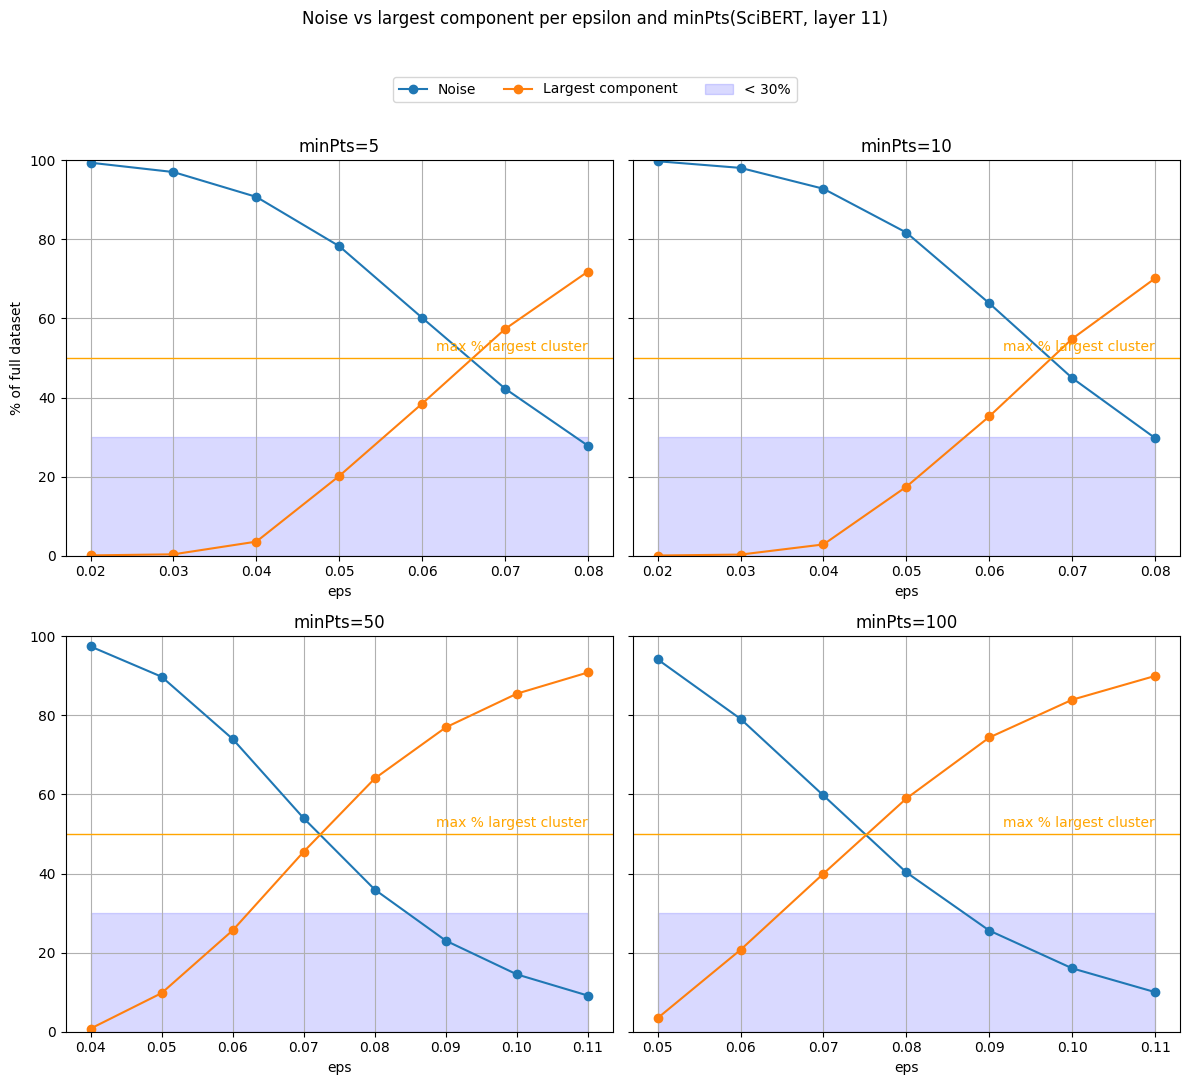

In [55]:
plot_noise_largest_component(
    "../results/dbscan_sample/clustering_results_scibert_layer_11.json",
    "SciBERT, layer 11"
)

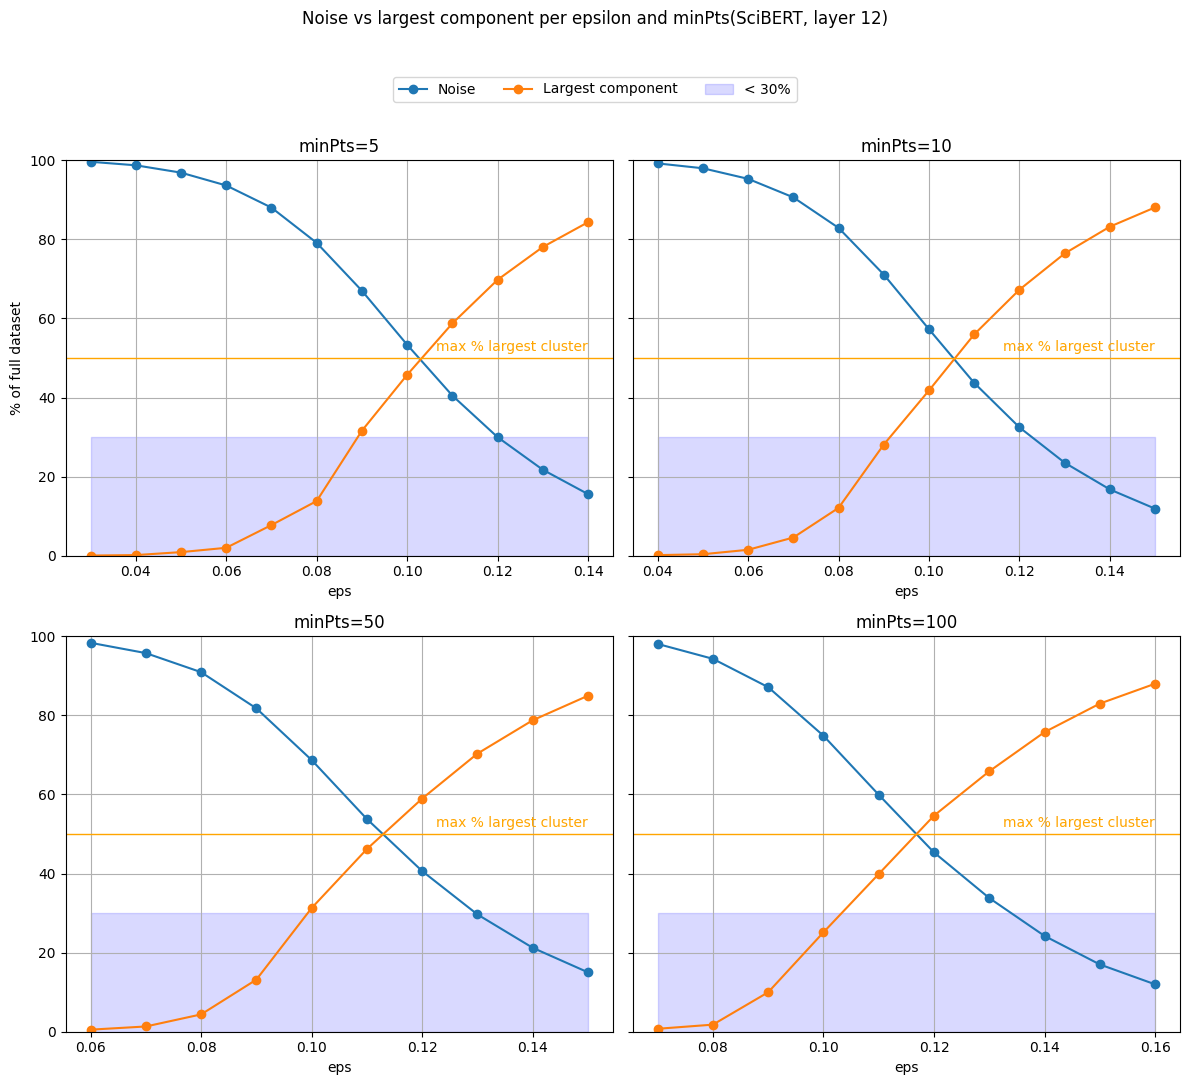

In [56]:
plot_noise_largest_component(
    "../results/dbscan_sample/clustering_results_scibert_layer_12.json",
    "SciBERT, layer 12"
)

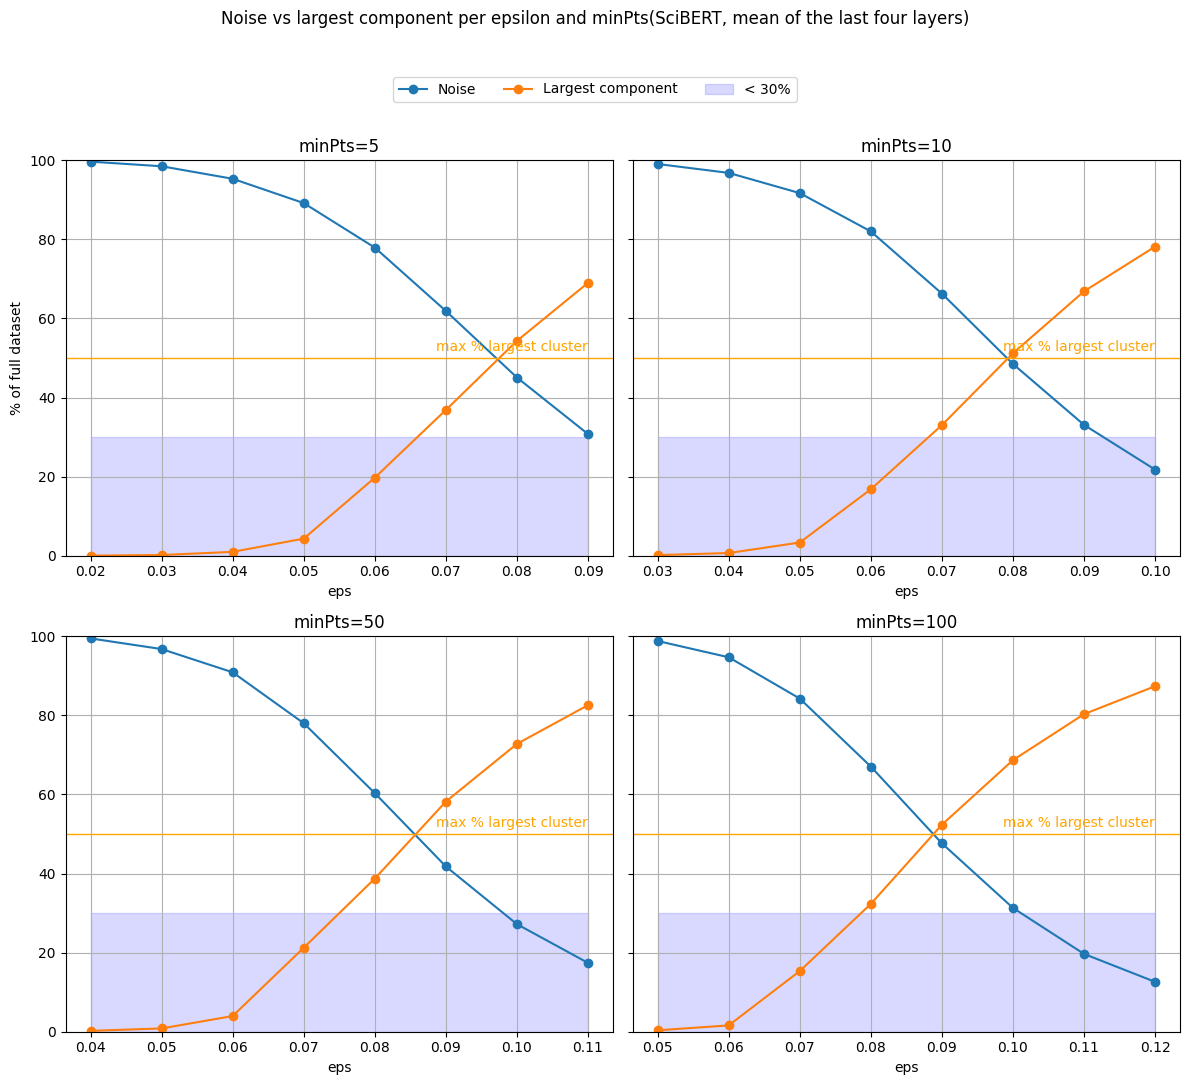

In [57]:
plot_noise_largest_component(
    "../results/dbscan_sample/clustering_results_scibert_layer_mean.json",
    "SciBERT, mean of the last four layers"
)

# DBCV

## define the dbcv vis function

In [73]:
import json
import matplotlib.pyplot as plt
import numpy as np


def plot_dbcv(filename, title):
    with open(filename, "r") as f:
        clustering_results = json.load(f)

    minPts_values = sorted({
        result["min_samples"]
        for result in clustering_results.values()
    })

    # Get all unique eps values
    eps_values = sorted({
        result["eps"]
        for result in clustering_results.values()
    })

    # Width of each individual bar
    bar_width = 0.8 / len(minPts_values)

    # Positions of the eps groups
    x = np.arange(len(eps_values))

    plt.figure(figsize=(12, 6))

    for i, minPts in enumerate(minPts_values):

        dbcv_values = []

        for eps in eps_values:
            matching_results = [
                result
                for result in clustering_results.values()
                if (
                    result["min_samples"] == minPts
                    and result["eps"] == eps
                )
            ]

            if matching_results:
                dbcv_values.append(matching_results[0]["dbcv"][0])
            else:
                dbcv_values.append(np.nan)

        # Offset each minPts within the eps group
        offset = (i - (len(minPts_values) - 1) / 2) * bar_width

        plt.bar(
            x + offset,
            dbcv_values,
            width=bar_width,
            label=f"minPts={minPts}"
        )

    # Use eps values as x-axis labels
    plt.xticks(x, eps_values)

    plt.xlabel("eps")
    plt.ylabel("DBCV")
    plt.title(
        f"Density Based Clustering Validation (DBCV) "
        f"with varying epsilon and minPts ({title})"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


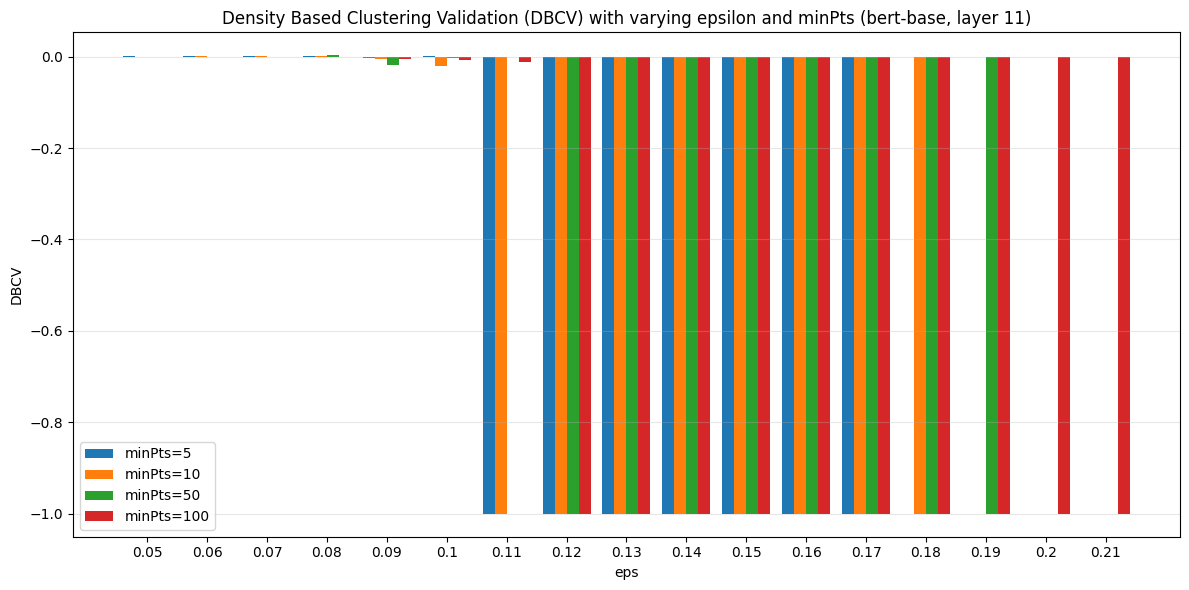

In [74]:
plot_dbcv(
    "../results/dbscan_sample/clustering_results_bert-base_layer_11.json",
    "bert-base, layer 11"
)

## maybe a table makes more sense

In [3]:
import json
with open("../results/dbscan_sample/clustering_results_bert-base_layer_11.json", "r") as f: 
        clustering_results = json.load(f)

In [4]:
clustering_results.keys()

dict_keys(['eps_0.0500_minPts_5', 'eps_0.0600_minPts_5', 'eps_0.0700_minPts_5', 'eps_0.0800_minPts_5', 'eps_0.0900_minPts_5', 'eps_0.1000_minPts_5', 'eps_0.1100_minPts_5', 'eps_0.1200_minPts_5', 'eps_0.1300_minPts_5', 'eps_0.1400_minPts_5', 'eps_0.1500_minPts_5', 'eps_0.1600_minPts_5', 'eps_0.1700_minPts_5', 'eps_0.0600_minPts_10', 'eps_0.0700_minPts_10', 'eps_0.0800_minPts_10', 'eps_0.0900_minPts_10', 'eps_0.1000_minPts_10', 'eps_0.1100_minPts_10', 'eps_0.1200_minPts_10', 'eps_0.1300_minPts_10', 'eps_0.1400_minPts_10', 'eps_0.1500_minPts_10', 'eps_0.1600_minPts_10', 'eps_0.1700_minPts_10', 'eps_0.1800_minPts_10', 'eps_0.0800_minPts_50', 'eps_0.0900_minPts_50', 'eps_0.1000_minPts_50', 'eps_0.1100_minPts_50', 'eps_0.1200_minPts_50', 'eps_0.1300_minPts_50', 'eps_0.1400_minPts_50', 'eps_0.1500_minPts_50', 'eps_0.1600_minPts_50', 'eps_0.1700_minPts_50', 'eps_0.1800_minPts_50', 'eps_0.1900_minPts_50', 'eps_0.0900_minPts_100', 'eps_0.1000_minPts_100', 'eps_0.1100_minPts_100', 'eps_0.1200_min

### Why is there a none stored with the dbcv value?

How I ran it in the code:  
score = DBCV_score(embeddings_norm, labels)  

According to gemini:  
"The kDBCV library returns a tuple structured as (overall_dbcv_score, individual_cluster_scores) when called."  

Check with the doc:  
"By default, ind_clust_scores is set to False"  

Check in the github code:  
https://github.com/Kaufman-Lab-Columbia/k-DBCV/blob/main/kDBCV/DBCV.py  
"def DBCV_score(  
    X: npt.NDArray[np.float_],  
    labels: npt.NDArray[np.int_],  
    ind_clust_scores: bool = False,  
    mem_cutoff: float = 25.0,  
    batch_mode = False  
) -> Tuple[float, Optional[List[float]]]:"  

"    Returns:  
        Tuple containing:  
            - float: The aggregate DBCV score for the input data.  
            - Optional[List[float]]: The list of individual DBCV scores for each  
              cluster. Only returned if ind_clust_scores is set to True, otherwise  
              returned as None."  

I mean returns sound like it returns a tuple [dbcv, list of cluster dbsv OR None] - I can live with this  

In [1]:
import pandas as pd
import json
from pathlib import Path


dfs = []

for filepath in Path("../results/dbscan_sample/").glob("*.json"):
    with open(filepath, "r") as f: 
        clustering_results = json.load(f)

    df = pd.DataFrame.from_dict(clustering_results, orient="index")
    df["dbcv"] = df["dbcv"].apply(lambda x: x[0])
    df["file_name"] = filepath
    
    dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)

In [2]:
print(all_results.shape)
print(all_results["model"].value_counts())
print(all_results["min_samples"].value_counts())

(251, 13)
model
bert-base    146
scibert      105
Name: count, dtype: int64
min_samples
5      66
10     65
50     61
100    59
Name: count, dtype: int64


In [35]:
all_results.groupby(["model", "layer"])["dbcv"].max()

model      layer     
bert-base  layer_11      0.002830
           layer_12      0.020058
           mean          0.008152
scibert    layer_11      0.051028
           layer_12      0.008310
           layer_mean    0.005633
Name: dbcv, dtype: float64

In [43]:
all_results.loc[
        all_results.groupby(["model", "layer"])["dbcv"].idxmax()
    ].sort_values("dbcv", ascending=False)[
        ["model", "layer", "eps", "min_samples", "dbcv"]
        ]

,model,layer,eps,min_samples,dbcv
170,scibert,layer_11,0.07,100,0.051028
95,bert-base,layer_12,0.13,100,0.020058
200,scibert,layer_12,0.07,50,0.008310
131,bert-base,mean,0.11,50,0.008152
222,scibert,layer_mean,0.05,5,0.005633
26,bert-base,layer_11,0.08,50,0.002830


In [41]:
top_2 = ( 
    all_results 
    .sort_values("dbcv", ascending=False) 
    .groupby(["model", "layer"]) 
    .head(2) 
    [["model", "layer", "eps", "min_samples", "dbcv"]] 
    )

top_2

,model,layer,eps,min_samples,dbcv
170,scibert,layer_11,0.07,100,0.051028
95,bert-base,layer_12,0.13,100,0.020058
94,bert-base,layer_12,0.12,100,0.009414
200,scibert,layer_12,0.07,50,0.008310
131,bert-base,mean,0.11,50,0.008152
189,scibert,layer_12,0.06,10,0.006220
222,scibert,layer_mean,0.05,5,0.005633
148,scibert,layer_11,0.04,5,0.004126
221,scibert,layer_mean,0.04,5,0.004125
104,bert-base,mean,0.06,5,0.003261


# nr of clusters with top 3 dbcv

## update the nr_clusters function

In [6]:
import json
import matplotlib.pyplot as plt


def plot_clustering_results(
    filename,
    title,
    highlight_points=None
):
    with open(filename, "r") as f:
        clustering_results = json.load(f)

    plt.figure(figsize=(9, 6))

    # Plot number of clusters
    for minPts in sorted({
        result["min_samples"]
        for result in clustering_results.values()
    }):
        results = [
            result
            for result in clustering_results.values()
            if result["min_samples"] == minPts
        ]

        results = sorted(results, key=lambda x: x["eps"])

        eps = [result["eps"] for result in results]
        n_clusters = [result["n_clusters"] for result in results]

        plt.plot(
            eps,
            n_clusters,
            marker="o",
            label=f"minPts={minPts}"
        )

    # Highlight selected points
    if highlight_points:
        highlight_colors = ["yellow", "grey", "brown"]
        highlight_labels = ["Best", "Second best", "Third best"]

        for point, color, rank in zip(
            highlight_points[:3],
            highlight_colors,
            highlight_labels
        ):
            # Find corresponding clustering result
            matching_results = [
                result
                for result in clustering_results.values()
                if (
                    result["eps"] == point["eps"]
                    and result["min_samples"] == point["min_samples"]
                )
            ]

            if not matching_results:
                print(
                    f"Warning: no result found for "
                    f"eps={point['eps']}, min_samples={point['min_samples']}"
                )
                continue

            result = matching_results[0]

            plt.scatter(
                point["eps"],
                result["n_clusters"],
                marker="*",
                s=200,
                color=color,
                edgecolor="black",
                zorder=10,
                label=f"{rank} (dbcv={point['dbcv']:.5f}, minPts={point['min_samples']})"
            )

    plt.xlabel("eps")
    plt.ylabel("Number of clusters")
    plt.title(
        f"Number of clusters with varying epsilon and minPts ({title})"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [7]:
def get_highlight_points(df, model, layer):
    top_3 = (
        df[
            (df["model"] == model) &
            (df["layer"] == layer)
        ]
        .sort_values("dbcv", ascending=False)
        .head(3)
    )

    highlight_points = [
        {
            "eps": row["eps"],
            "min_samples": row["min_samples"],
            "dbcv": row["dbcv"]
        }
        for _, row in top_3.iterrows()
    ]

    return highlight_points

## bert-base

In [8]:
highlight_points = get_highlight_points( all_results, model="bert-base", layer="layer_11" )

plot_clustering_results(
    "../results/dbscan_sample/clustering_results_bert-base_layer_11.json",
    "bert-base, layer 11",
    highlight_points=highlight_points
)

NameError: name 'all_results' is not defined

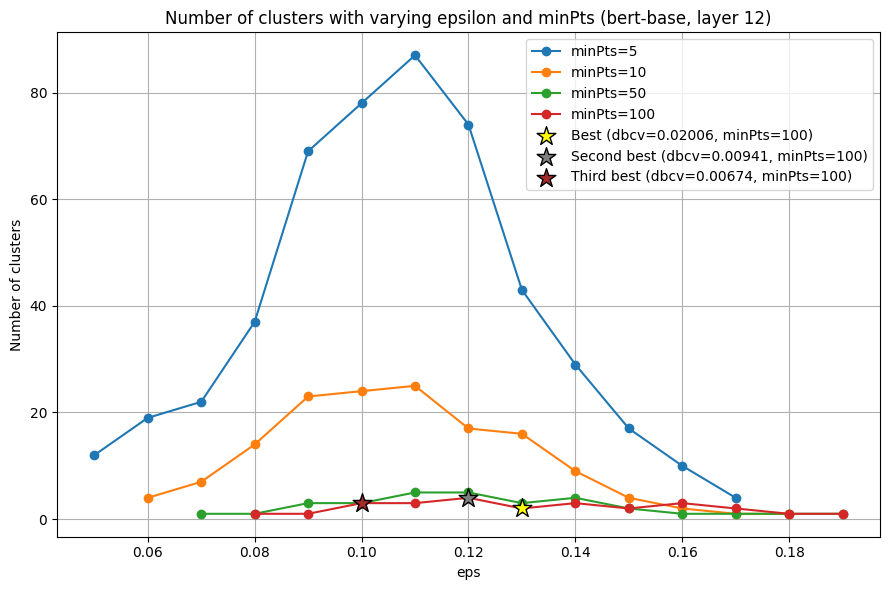

In [67]:
highlight_points = get_highlight_points( all_results, model="bert-base", layer="layer_12" )

plot_clustering_results(
    "../results/dbscan_sample/clustering_results_bert-base_layer_12.json",
    "bert-base, layer 12",
    highlight_points=highlight_points
)

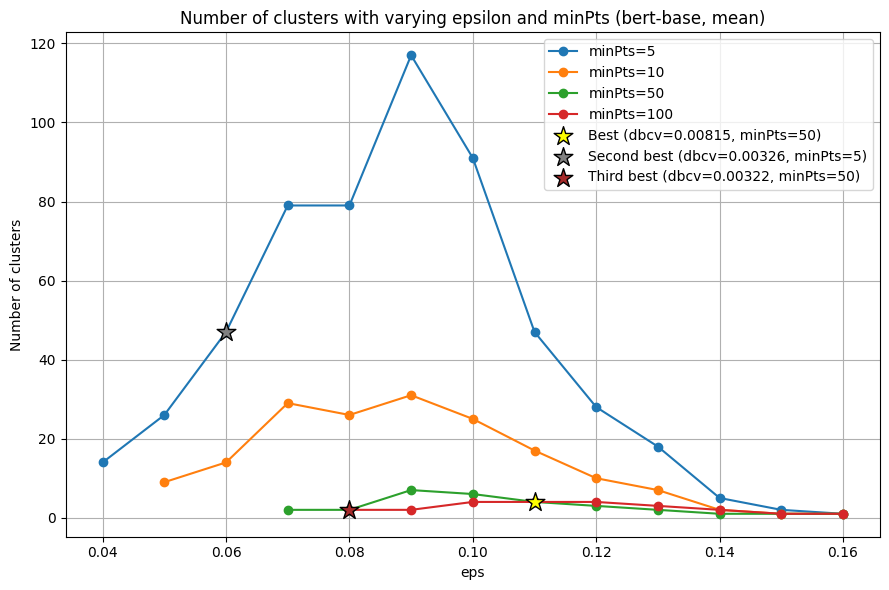

In [68]:
highlight_points = get_highlight_points( all_results, model="bert-base", layer="mean" )

plot_clustering_results(
    "../results/dbscan_sample/clustering_results_bert-base_mean.json",
    "bert-base, mean",
    highlight_points=highlight_points
)

## SciBERT

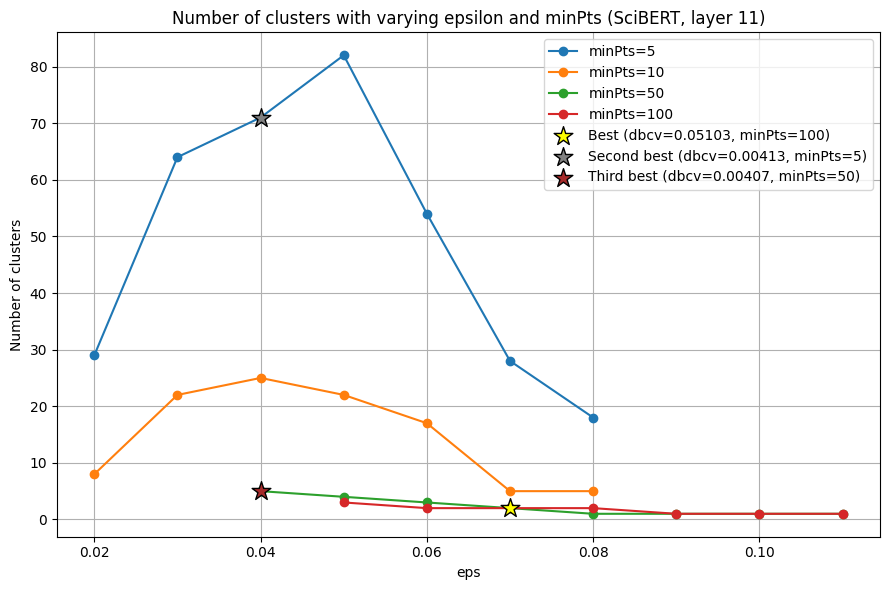

In [69]:
highlight_points = get_highlight_points( all_results, model="scibert", layer="layer_11" )

plot_clustering_results(
    "../results/dbscan_sample/clustering_results_scibert_layer_11.json",
    "SciBERT, layer 11",
    highlight_points=highlight_points
)

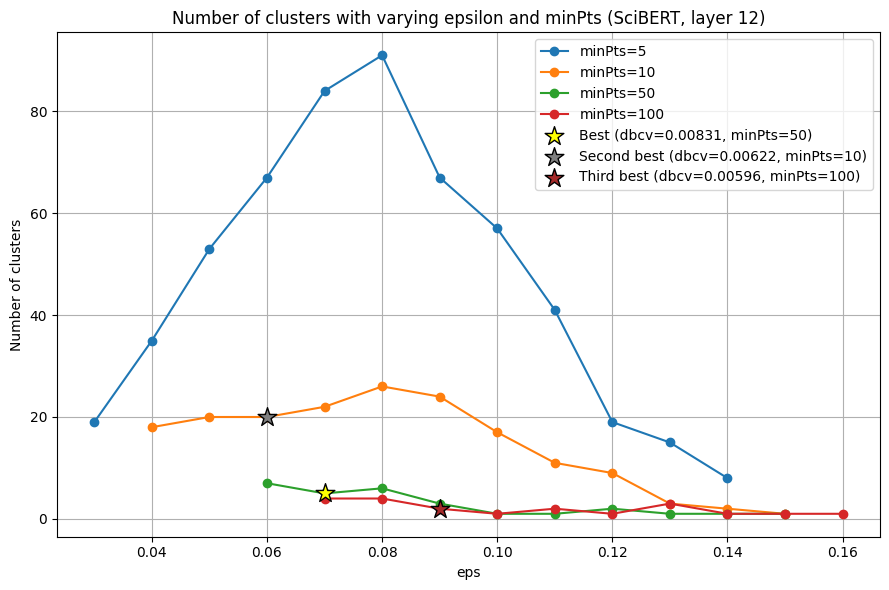

In [70]:
highlight_points = get_highlight_points( all_results, model="scibert", layer="layer_12" )

plot_clustering_results(
    "../results/dbscan_sample/clustering_results_scibert_layer_12.json",
    "SciBERT, layer 12",
    highlight_points=highlight_points
)

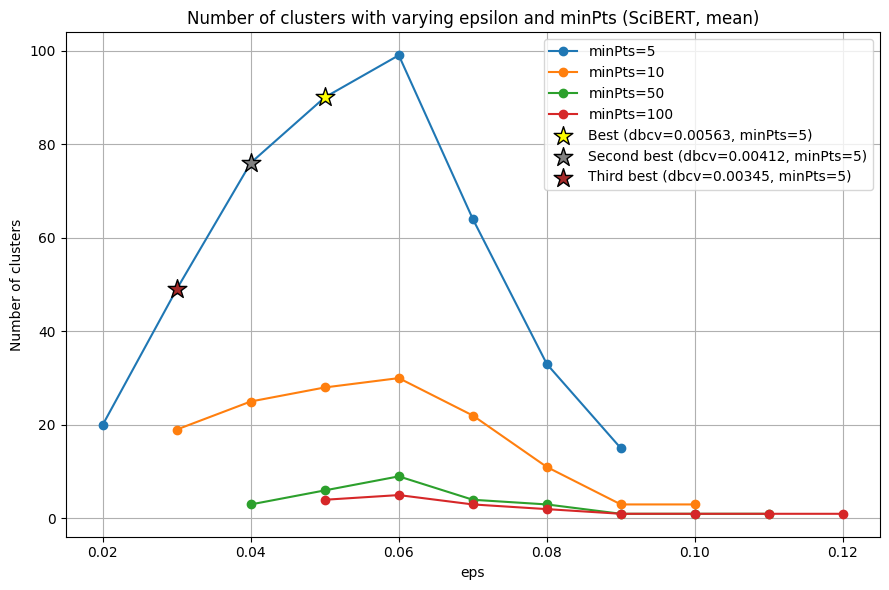

In [71]:
highlight_points = get_highlight_points( all_results, model="scibert", layer="layer_mean" )

plot_clustering_results(
    "../results/dbscan_sample/clustering_results_scibert_layer_mean.json",
    "SciBERT, mean",
    highlight_points=highlight_points
)

# upadate the noise vs largest component with top 3 dbcv

## new function

In [75]:
import json
import matplotlib.pyplot as plt
import math


def plot_noise_largest_component(
    filename,
    title,
    highlight_points=None
):
    with open(filename, "r") as f:
        clustering_results = json.load(f)

    minPts_values = sorted({
        result["min_samples"]
        for result in clustering_results.values()
    })

    # Two plots per row
    n_cols = 2
    n_rows = math.ceil(len(minPts_values) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 5 * n_rows),
        sharey=True,
    )

    # Make axes iterable
    axes = axes.flatten()

    for ax, minPts in zip(axes, minPts_values):

        results = [
            result
            for result in clustering_results.values()
            if result["min_samples"] == minPts
        ]

        results = sorted(results, key=lambda x: x["eps"])

        eps = [
            result["eps"]
            for result in results
        ]

        # Noise as % of full dataset
        noise_pct = [
            100 * result["n_noise"] /
            result.get("n_samples", len(result["labels"]))
            for result in results
        ]

        # Largest component as % of full dataset
        largest_component_pct = [
            result["largest_cluster_pct"]
            for result in results
        ]

        # --------------------------------------------------------
        # Main lines
        # --------------------------------------------------------

        ax.plot(
            eps,
            noise_pct,
            marker="o",
            label="Noise"
        )

        ax.plot(
            eps,
            largest_component_pct,
            marker="o",
            label="Largest component"
        )

        # --------------------------------------------------------
        # Reference areas
        # --------------------------------------------------------

        ax.fill_between(
            eps,
            0,
            30,
            color="blue",
            alpha=0.15,
            label="< 30%"
        )

        ax.axhline(50, color="orange", linewidth=1)

        ax.text(
            eps[-1],
            51,
            "max % largest cluster",
            color="orange",
            va="bottom",
            ha="right"
        )

        # --------------------------------------------------------
        # Highlight top DBCV results
        # --------------------------------------------------------

        if highlight_points:
            highlight_colors = ["yellow", "grey", "brown"]
            highlight_labels = [
                "Best DBCV",
                "Second best DBCV",
                "Third best DBCV"
            ]

            for point, color, label in zip(
                highlight_points[:3],
                highlight_colors,
                highlight_labels
            ):
                # Only show the point in the subplot
                # corresponding to its min_samples
                if point["min_samples"] != minPts:
                    continue

                ax.axvline(
                    x=point["eps"],
                    color=color,
                    linewidth=2,
                    linestyle="--",
                    label=f"{label} ({point['dbcv']:.5f})",
                    zorder=5
                )

        # --------------------------------------------------------
        # Formatting
        # --------------------------------------------------------

        ax.set_xlabel("eps")
        ax.set_title(f"minPts={minPts}")
        ax.set_ylim(0, 100)
        ax.grid(True)

    # Hide unused subplot if there is an odd number of minPts values
    for ax in axes[len(minPts_values):]:
        ax.set_visible(False)

    # Shared y-axis label
    axes[0].set_ylabel("% of full dataset")

    # One shared legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 1.02)
    )

    fig.suptitle(
        f"Noise vs largest component per epsilon and minPts ({title})",
        y=1.08
    )

    plt.tight_layout()
    plt.show()

## bert-base

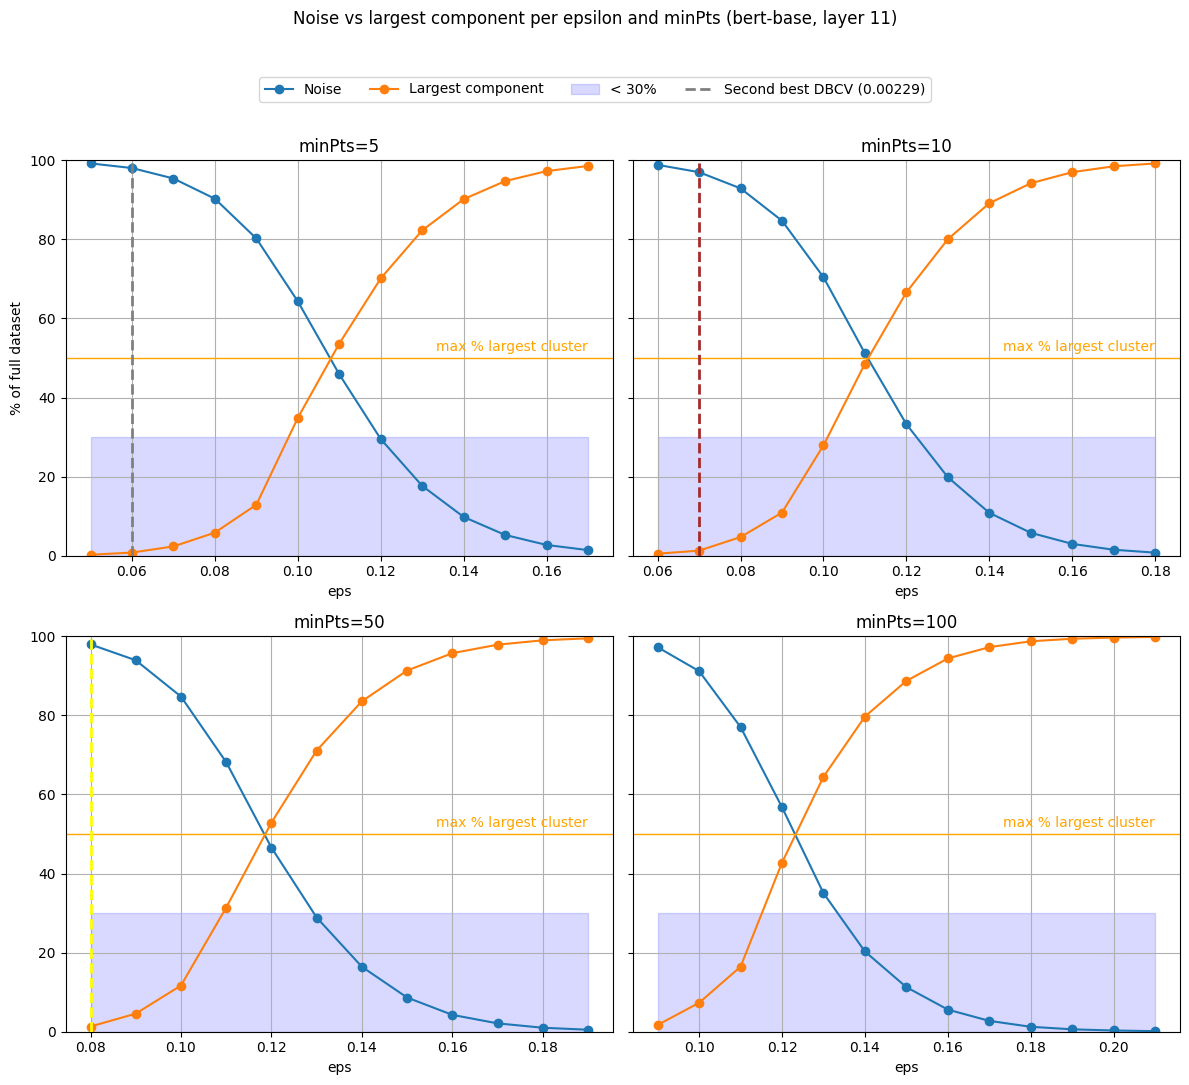

In [76]:
highlight_points = get_highlight_points( 
    all_results, 
    model="bert-base", 
    layer="layer_11" 
    ) 
    
    
plot_noise_largest_component( 
    "../results/dbscan_sample/clustering_results_bert-base_layer_11.json", 
    "bert-base, layer 11", 
    highlight_points=highlight_points 
    )

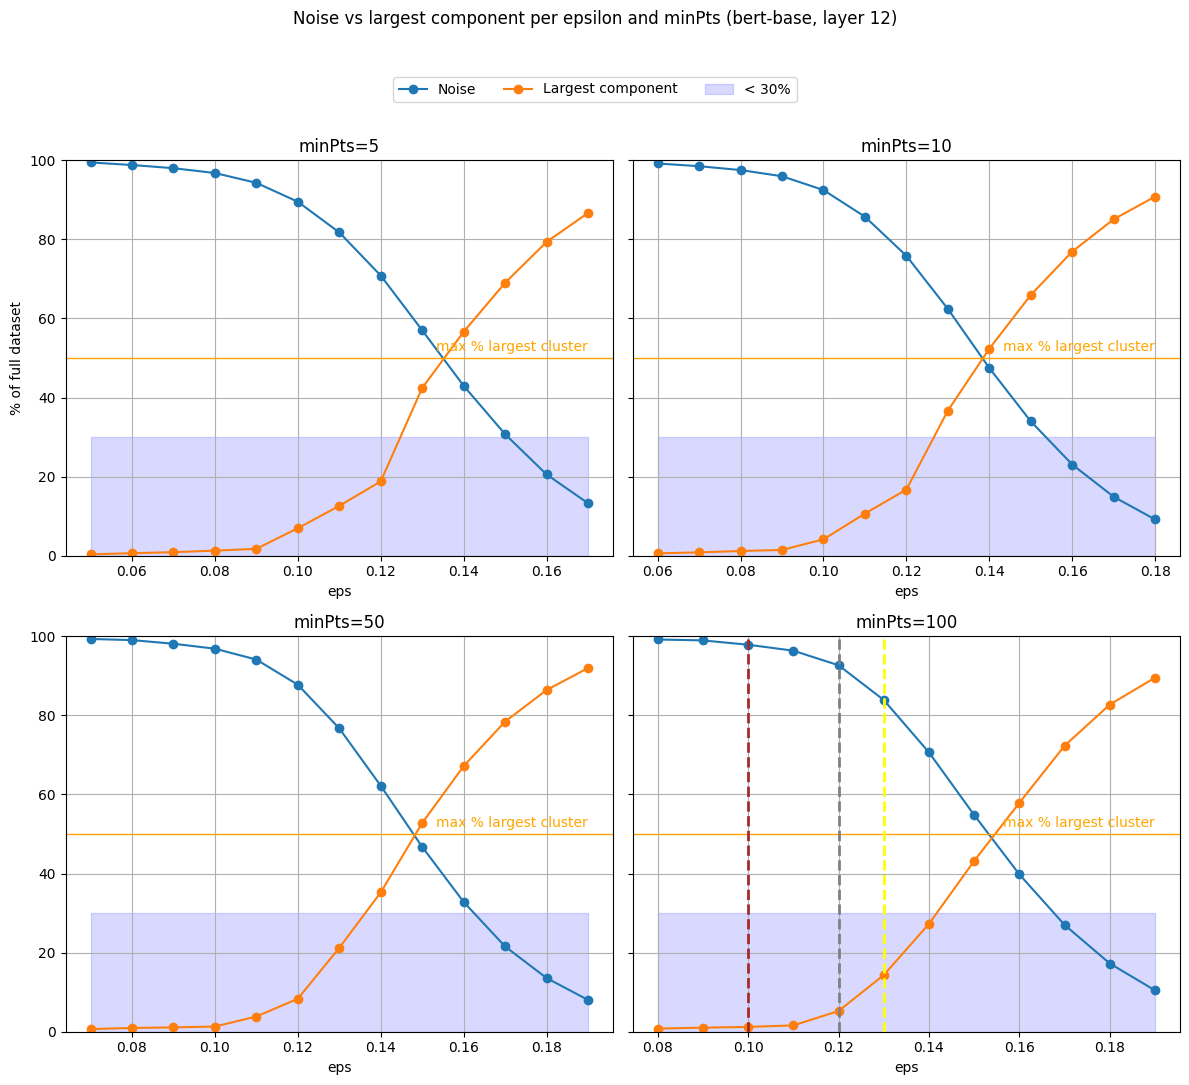

In [77]:
highlight_points = get_highlight_points( 
    all_results, 
    model="bert-base", 
    layer="layer_12" 
    ) 
    
    
plot_noise_largest_component( 
    "../results/dbscan_sample/clustering_results_bert-base_layer_12.json", 
    "bert-base, layer 12", 
    highlight_points=highlight_points 
    )

okay, here I will probably set up 4 runs - the best performing one and then as before the once that are increasing by 0.1 the eps  

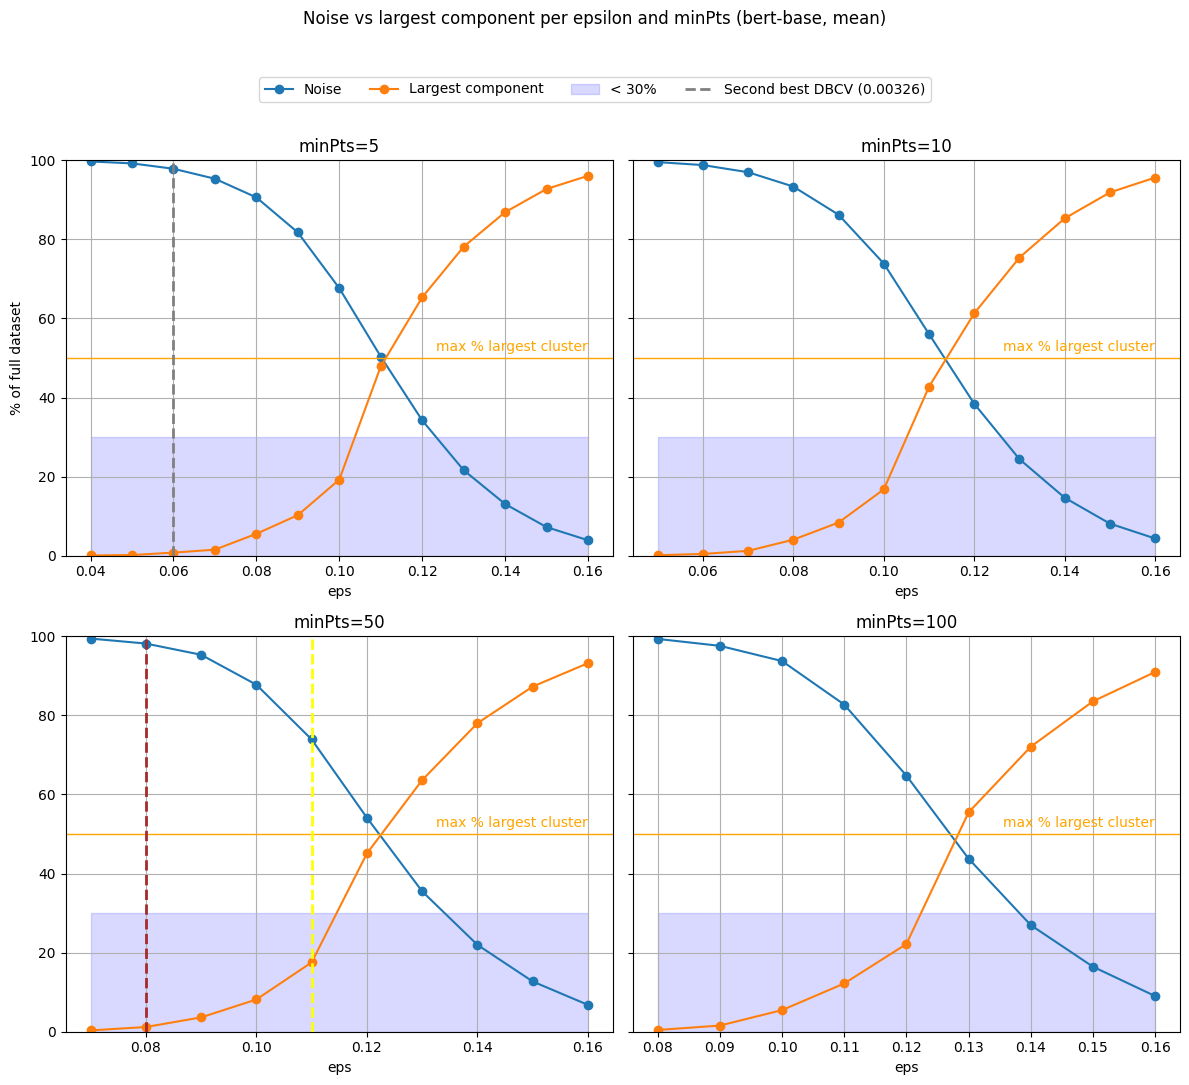

In [78]:
highlight_points = get_highlight_points( 
    all_results, 
    model="bert-base", 
    layer="mean" 
    ) 
    
    
plot_noise_largest_component( 
    "../results/dbscan_sample/clustering_results_bert-base_mean.json", 
    "bert-base, mean", 
    highlight_points=highlight_points 
    )

## SciBERT

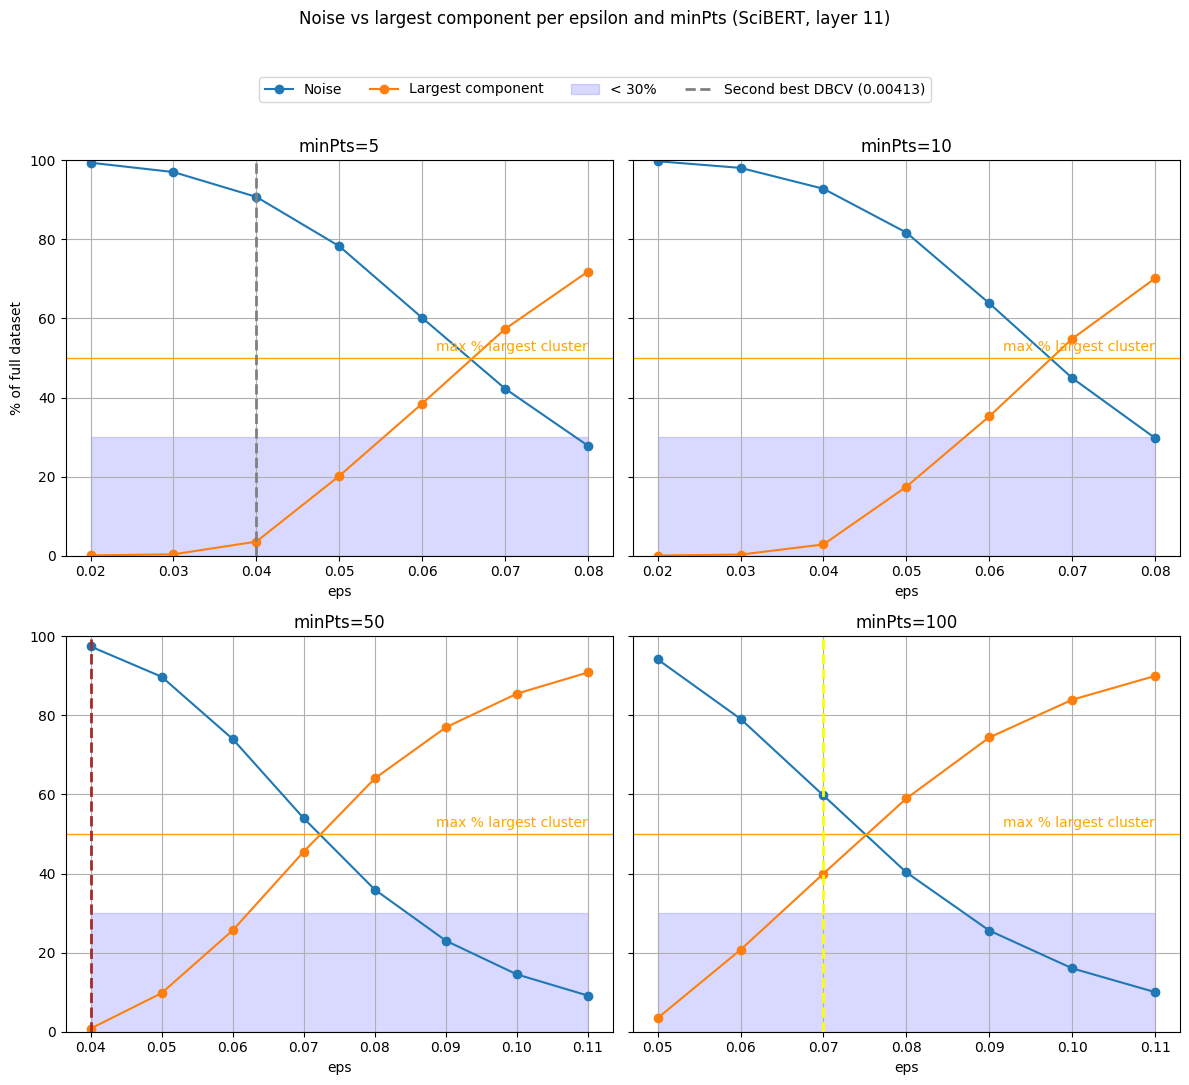

In [79]:
highlight_points = get_highlight_points( 
    all_results, 
    model="scibert", 
    layer="layer_11" 
    ) 
    
    
plot_noise_largest_component( 
    "../results/dbscan_sample/clustering_results_scibert_layer_11.json", 
    "SciBERT, layer 11", 
    highlight_points=highlight_points 
    )

At SciBERT layer 11 is the best performing dbcv over all runs.  
Additionally the noise (~60%) and largest cluster (~40%) ratio are also among the best. while the largest cluster is fine, the noise would be considered too high.  

On the whole sample, I would like to test the best performing one as well as with two slightly higher eps (0.08 and 0.09) - since the noise ratio should be improving and the numbers of clusters is fairly stable

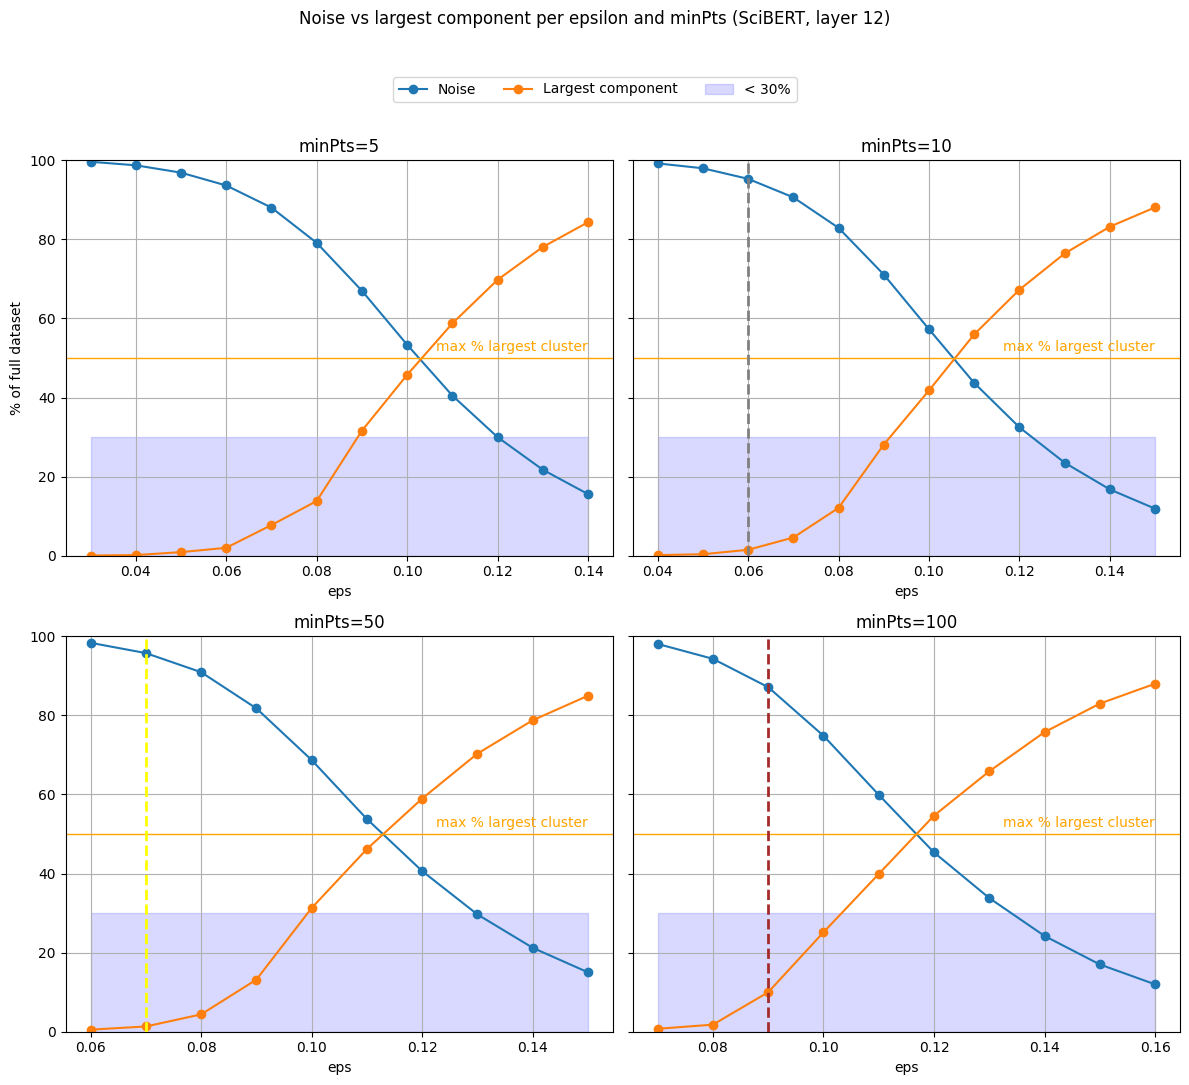

In [80]:
highlight_points = get_highlight_points( 
    all_results, 
    model="scibert", 
    layer="layer_12" 
    ) 
    
    
plot_noise_largest_component( 
    "../results/dbscan_sample/clustering_results_scibert_layer_12.json", 
    "SciBERT, layer 12", 
    highlight_points=highlight_points 
    )

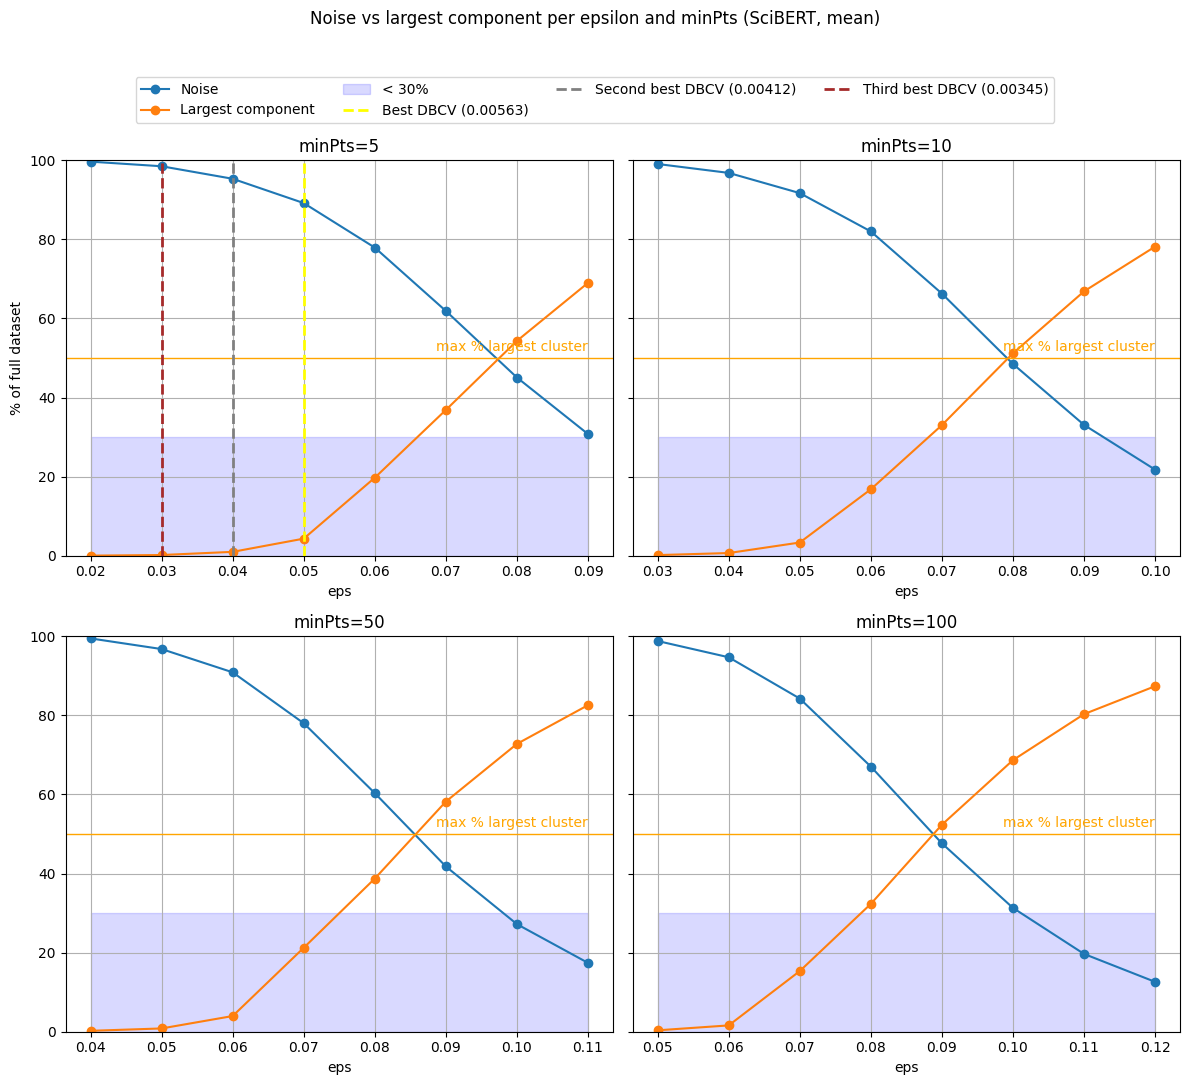

In [81]:
highlight_points = get_highlight_points( 
    all_results, 
    model="scibert", 
    layer="layer_mean" 
    ) 
    
    
plot_noise_largest_component( 
    "../results/dbscan_sample/clustering_results_scibert_layer_mean.json", 
    "SciBERT, mean", 
    highlight_points=highlight_points 
    )